In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
test = pd.read_csv(
    "../data/processed/test.csv"
)

model = joblib.load(
    "../models/random_forest_waste_model.pkl"
)

preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

print("Test shape:", test.shape)

Test shape: (26140, 60)


In [3]:
import sys

sys.path.append("../src")

from preprocessing import prepare_features

X_test, y_test = prepare_features(test)

X_test_processed = preprocessor.transform(
    X_test
)

predictions = model.predict(
    X_test_processed
)

print("Predictions generated:", len(predictions))

Predictions generated: 26140


In [4]:
results = test[
    [
        "reading_id",
        "bin_id",
        "timestamp",
        "sensor_fill_level_pct",
        "area_type"
    ]
].copy()

results["actual_fill_6h"] = y_test.values
results["predicted_fill_6h"] = predictions

results["absolute_error"] = (
    results["actual_fill_6h"]
    - results["predicted_fill_6h"]
).abs()

results.head(10)

,reading_id,bin_id,timestamp,sensor_fill_level_pct,area_type,actual_fill_6h,predicted_fill_6h,absolute_error
0,R00007430,B0001,2026-06-06 13:00:00,28.187688,School,27.474914,27.589289,0.114374
1,R00007431,B0001,2026-06-06 14:00:00,27.321390,School,27.538439,27.433015,0.105424
2,R00007432,B0001,2026-06-06 15:00:00,24.124627,School,27.539166,27.638629,0.099462
3,R00007433,B0001,2026-06-06 16:00:00,31.182418,School,27.570930,27.156800,0.414130
4,R00007434,B0001,2026-06-06 17:00:00,26.945121,School,27.655936,27.984262,0.328326
5,R00007435,B0001,2026-06-06 18:00:00,26.575259,School,27.674752,27.773315,0.098562
6,R00007436,B0001,2026-06-06 19:00:00,27.998127,School,27.679740,27.815764,0.136024
7,R00007437,B0001,2026-06-06 20:00:00,23.777109,School,27.714202,27.738157,0.023955
8,R00007438,B0001,2026-06-06 21:00:00,27.407559,School,27.739709,27.580538,0.159172
9,R00007439,B0001,2026-06-06 22:00:00,27.097052,School,27.829241,28.069361,0.240120


In [5]:
worst_predictions = results.sort_values(
    "absolute_error",
    ascending=False
).head(20)

worst_predictions

,reading_id,bin_id,timestamp,sensor_fill_level_pct,area_type,actual_fill_6h,predicted_fill_6h,absolute_error
3361,R00025697,B0003,2026-07-07 16:00:00,17.497201,Commercial,20.962654,28.326246,7.363592
25310,R00174347,B0020,2026-06-26 10:00:00,13.083734,Residential,10.941628,15.611585,4.669957
474,R00007904,B0001,2026-06-26 07:00:00,9.568194,School,20.474809,15.830329,4.644480
4548,R00034337,B0004,2026-07-02 16:00:00,13.093276,Industrial,10.150359,14.709175,4.558816
15904,R00112770,B0013,2026-06-15 17:00:00,32.712854,School,32.438429,36.741828,4.303399
25312,R00174349,B0020,2026-06-26 12:00:00,4.782361,Residential,11.760148,7.521853,4.238295
10482,R00077536,B0009,2026-06-07 15:00:00,52.624594,Commercial,53.664324,57.865139,4.200815
4380,R00034169,B0004,2026-06-25 16:00:00,6.851066,Industrial,4.532635,8.710390,4.177755
475,R00007905,B0001,2026-06-26 08:00:00,16.208843,School,20.982444,16.827345,4.155099
1102,R00008532,B0001,2026-07-22 11:00:00,12.537342,School,10.851713,14.908755,4.057042


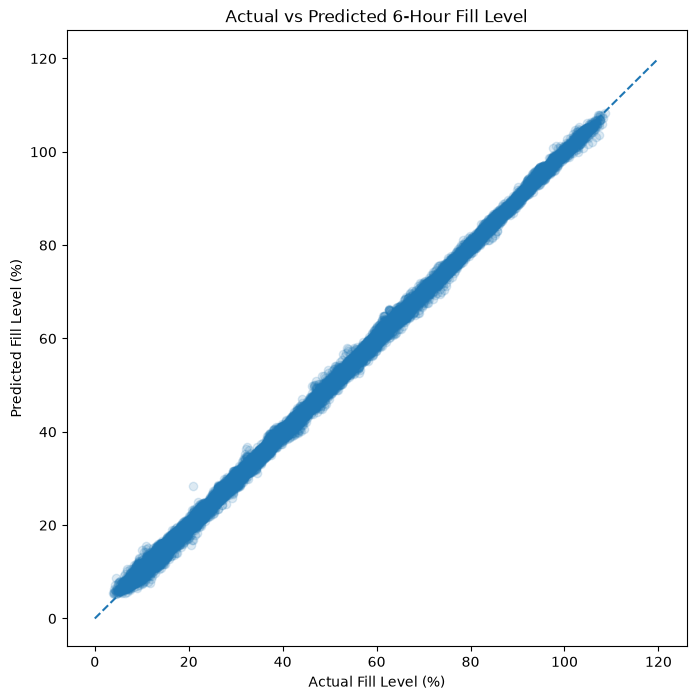

In [6]:
plt.figure(figsize=(8, 8))

plt.scatter(
    results["actual_fill_6h"],
    results["predicted_fill_6h"],
    alpha=0.15
)

plt.xlabel("Actual Fill Level (%)")
plt.ylabel("Predicted Fill Level (%)")
plt.title("Actual vs Predicted 6-Hour Fill Level")

plt.plot(
    [0, 120],
    [0, 120],
    linestyle="--"
)

plt.show()

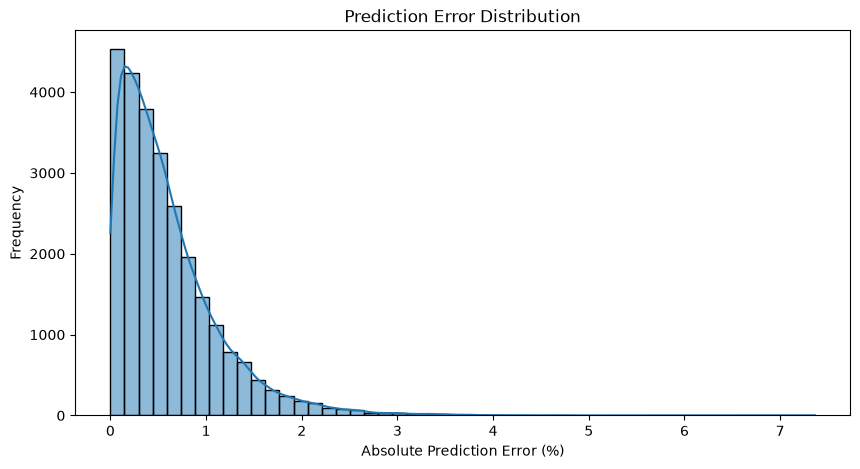

In [7]:
plt.figure(figsize=(10, 5))

sns.histplot(
    results["absolute_error"],
    bins=50,
    kde=True
)

plt.xlabel("Absolute Prediction Error (%)")
plt.ylabel("Frequency")
plt.title("Prediction Error Distribution")

plt.show()

In [8]:
print(
    results["absolute_error"].describe()
)

count    26140.000000
mean         0.598941
std          0.531446
min          0.000074
25%          0.216750
50%          0.465169
75%          0.823611
max          7.363592
Name: absolute_error, dtype: float64


In [9]:
print(
    "Predictions with error <= 5%:",
    (
        results["absolute_error"] <= 5
    ).mean() * 100
)

Predictions with error <= 5%: 99.99617444529457


In [10]:
error_by_area = (
    results
    .groupby("area_type")["absolute_error"]
    .agg(
        ["mean", "median", "max", "count"]
    )
    .sort_values("mean", ascending=False)
)

error_by_area

,mean,median,max,count
area_type,,,,
School,0.796914,0.596771,4.644480,3921
Public_Park,0.718712,0.554766,3.361295,1307
Hospital,0.660827,0.540779,3.249560,1307
Commercial,0.598613,0.474947,7.363592,6535
Industrial,0.545000,0.433218,4.558816,3921
Market,0.513041,0.400323,3.582729,2614
Residential,0.510879,0.407610,4.669957,6535


In [11]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
)

feature_importance.head(20)

,feature,importance
4,numerical__sensor_fill_level_pct,0.507768
42,numerical__capacity_remaining_pct,0.319946
22,numerical__avg_fill_6h_pct,0.168432
40,numerical__historical_avg_fill_pct,0.000603
5,numerical__hours_since_collection,0.000374
35,numerical__hour_cos,0.000303
23,numerical__avg_fill_24h_pct,0.000261
12,numerical__previous_fill_1h_pct,0.000171
3,numerical__demand_multiplier,0.000154
27,numerical__day_of_week,0.000152


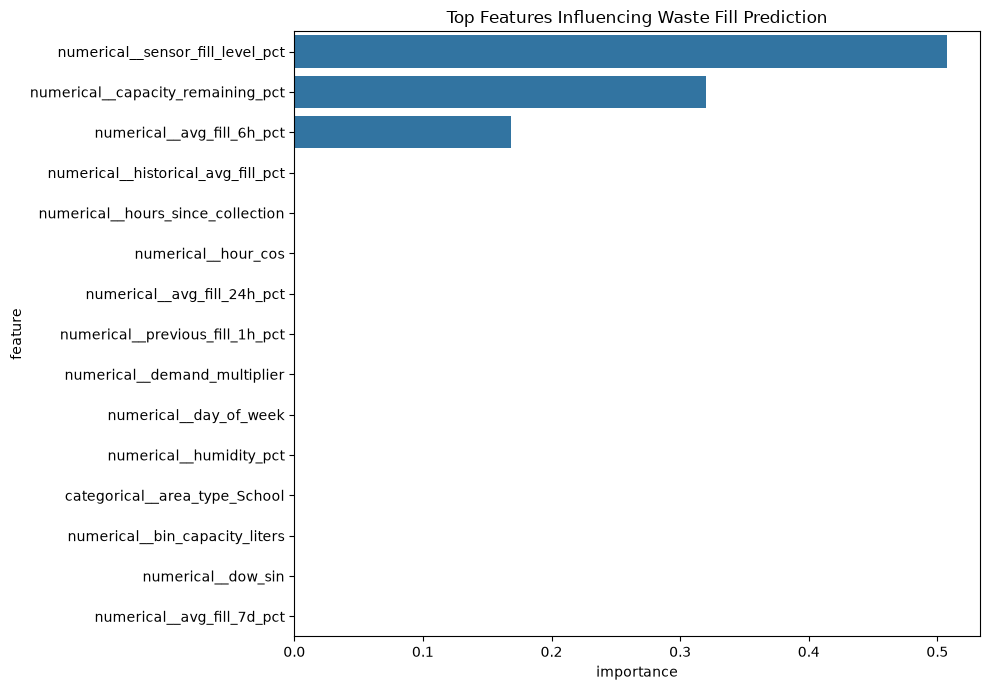

In [12]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title(
    "Top Features Influencing Waste Fill Prediction"
)

plt.tight_layout()
plt.show()

In [13]:
results.to_csv(
    "../data/processed/test_predictions.csv",
    index=False
)

print("Prediction results saved.")

Prediction results saved.
